In [129]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [186]:
gen = torch.Generator().manual_seed(42)
embed_size = 32
num_head = 4
head_size = embed_size // num_head
num_blocks = 4
batch_size = 32
block_size = 64
device = 'mps' if torch.backends.mps.is_available() else 'cpu'

In [187]:
text = open('../input.txt').read()
alph =  sorted(list(set(text)))
alph_size = len(alph)
stoi = {c: i for i, c in enumerate(alph)}
itos = {v: k for k, v in stoi.items()}
encode = lambda x: [stoi[c] for c in x]
decode = lambda x: ''.join([itos[ic] for ic in x])
n = int(0.9 * len(text))
Xtr = encode(text[:n])
Xval = encode(text[n:])
gen = torch.Generator().manual_seed(42)

def getbatch(X):
    starts = torch.randint(0, len(X) - block_size, (batch_size,), generator = gen)
    context = torch.tensor([X[st : st + block_size] for st in starts])
    target = torch.tensor([X[st + 1 : st + block_size + 1] for st in starts])
    return context, target

- try SwiGLU activation

- try Dropout in attention

- try RoPe positional enconding


In [197]:
class FeedForward(nn.Module):
    
    def __init__(self, embed_size):
        super().__init__()
        self.lin1 = nn.Linear(embed_size, embed_size * 4)
        self.act = nn.SiLU()
        self.lin2 = nn.Linear(embed_size * 4, embed_size)
    
    def forward(self, x):
        # (batch_size, block_size, embed_size)
        return self.lin2(self.act(self.lin1(x)))
        

class Block(nn.Module):
    
    def __init__(self, block_size, embed_size, num_head):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_size)
        self.attn = nn.MultiheadAttention(embed_size, num_head, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_size)
        self.ff = FeedForward(embed_size)
        mask = torch.triu(torch.ones(block_size, block_size), diagonal=1).bool()
        self.register_buffer('mask', mask)
    
    def forward(self, x):
        # (batch_size, block_size, embed_size)
        # adding residual connections!
        x = self.norm1(x)
        attMat = self.attn(key = x, query = x, value = x, attn_mask = self.mask[:x.shape[-2], :x.shape[-2]])[0]
        x = x + attMat
        x = x + self.ff(self.norm2(x))
        return x

class GPT(nn.Module):

    def __init__(self, block_size, alph_size, embed_size, num_head, num_blocks):
        super().__init__()
        self.block_size = block_size
        self.embedding = nn.Embedding(alph_size, embed_size)
        self.pos_embedding = nn.Embedding(block_size, embed_size)
        self.blocks = nn.Sequential(*[Block(block_size, embed_size, num_head) for _ in range(num_blocks)])
        self.norm = nn.LayerNorm(embed_size)
        self.linear = nn.Linear(embed_size, alph_size)
    
    def forward(self, x):
        # (batch_size, block_size), numbers from zero to alph_size - 1
        x_embed = self.embedding(x) # (batch_size, block_size, embed_size)
        x_pos_embed = self.pos_embedding(torch.arange(x.shape[-1])) # (block_size, embed_size)
        x_embed = x_embed + x_pos_embed # (batch_size, block_size, embed_size) + (block_size, embed_size) -> (batch_size, block_size, embed_size)
        logits = self.blocks(x_embed) # (batch_size, block_size, embed_size)
        logits = self.norm(logits) # (batch_size, block_size, embed_size)
        logits = self.linear(logits) # (batch_size, block_size, alph_size)
        return logits
    
    @torch.no_grad()
    def generate(self, context, gen_len):
        text = ''
        context = encode(context[-min(len(context), self.block_size):])
        for _ in range(gen_len):
            logits = self.__call__(torch.tensor([context]))
            ix = torch.multinomial(F.softmax(logits[-1, -1], -1), generator=gen, num_samples=1).item()
            text += itos[ix]
            if len(context) == block_size:
                context = context[1:]
            context = context + [ix]
        return text

In [198]:
model = GPT(block_size, alph_size, embed_size, num_head, num_blocks)

In [199]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

In [200]:
count_parameters(model)

57153

In [201]:
lossi = []

In [202]:
@torch.no_grad()
def getloss(X, num_samples):
    sumloss = 0
    for _ in range(num_samples):
        x, y = getbatch(X)
        logits = model(x)
        loss = F.cross_entropy(logits.view(batch_size * block_size, alph_size), y.view(batch_size * block_size))
        sumloss += loss
    return sumloss / num_samples

In [203]:
params = list(model.parameters())
lr = 1e-3
optimizer = torch.optim.AdamW(params, lr)
epochs = 3000
eval_every = 300
for e in range(epochs+1):
    x, y = getbatch(Xtr)
    model.train()

    logits = model(x)
    loss = F.cross_entropy(logits.view(batch_size * block_size, alph_size), y.view(batch_size * block_size))
    lossi.append(loss.item())
    optimizer.zero_grad()

    loss.backward()

    optimizer.step()
    if e % eval_every == 0:
        model.eval()
        print(f'Epoch {e}/{epochs}: train loss {getloss(Xtr, 100)}, val loss {getloss(Xval, 100)}')

Epoch 0/3000: train loss 4.356332302093506, val loss 4.355386734008789
Epoch 300/3000: train loss 2.548792600631714, val loss 2.5546584129333496
Epoch 600/3000: train loss 2.3749005794525146, val loss 2.379192590713501
Epoch 900/3000: train loss 2.257817268371582, val loss 2.2730491161346436
Epoch 1200/3000: train loss 2.164045810699463, val loss 2.193650960922241
Epoch 1500/3000: train loss 2.100396156311035, val loss 2.131272554397583
Epoch 1800/3000: train loss 2.0450315475463867, val loss 2.0879786014556885
Epoch 2100/3000: train loss 1.9921882152557373, val loss 2.0444300174713135
Epoch 2400/3000: train loss 1.9653935432434082, val loss 2.0223424434661865
Epoch 2700/3000: train loss 1.9155842065811157, val loss 2.003788709640503
Epoch 3000/3000: train loss 1.8968870639801025, val loss 1.9854165315628052


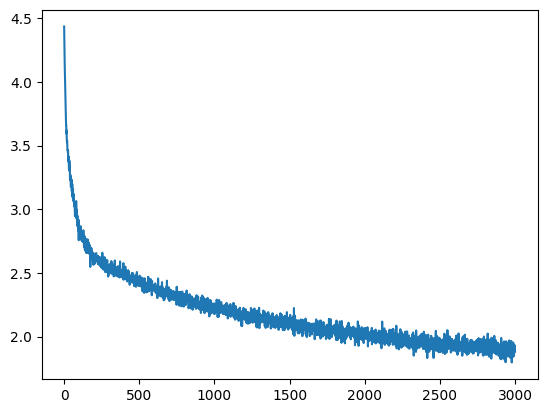

In [204]:
plt.plot(lossi);

In [205]:
print(model.generate('\n', 500))

Se, maint erscomid! Murs mady the dine: is I dright.

Clast, Ming sure unciat, So ints,
Ghes?

Firde quoter infulncess, the thy onculet,
And so sairst she of to seak the contor theirl.

DO livans the rown, so anit, it of not gulls rect hath a know
That whilk dobutersionh anty and dib ellas,
In of forcturplay a stach't torrk to greathpling mune;
Ther slorw from end. Dult saids are to menacl and his conpe,
To headctiofer you a sleect me mathwer!
Whid eltly and so nash; which my as dight.
'te to yo
